<a href="https://colab.research.google.com/github/Blacklotus89898/ComputerVisionMiscellaneous/blob/main/ecse_415_a4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision (ECSE 415)
## Assignment 4: Object Recognition

DEADLINE: November 17, 11:59 PM
Group: 21

Name: Steve Chen
ID: 261106847

In [ ]:
# Objective
"""The goal of this assignment is to develop and evaluate an object recognition model on a road sign
detection dataset, with the objective of gaining practical experience in applying deep learning methods
to object recognition tasks."""

# Dataset Description
"""Image Files: The Road Signs Detection dataset contains multiple categories of traffic signs (e.g.,
Speed Limits, Stop, Red Light, Green Light, etc.). Images are in .jpg format with a resolution of
416x416 and may contain one or more traffic signs per image.
Annotation Files (Labels): Each image has a corresponding YOLO-format text file (.txt) containing
one or more object annotations per line. Each line represents a detected traffic sign with the following
format:"""


## 0. Setup and Environment

In [ ]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import os
import pandas as pd
%matplotlib inline

In [ ]:
# Loading from the drive
from google.colab import drive
drive.mount('/content/drive') # drives takes forever to mount, for trainig, I might do it on my gpu or smth... or try to upload it directly under content

# Part 1
base_path1 = "/content/drive/MyDrive/ECSE415/a4/ecse-415-object-recognition/Road_Signs_Detection_Dataset"


## 1. Data Preparation

### 1.1 Explore the Dataset

3932.txt
3893.txt
4053.txt
42.txt
3919.txt


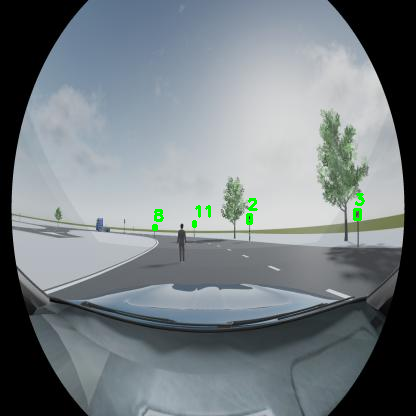

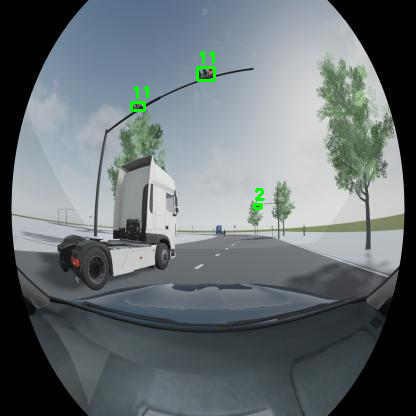

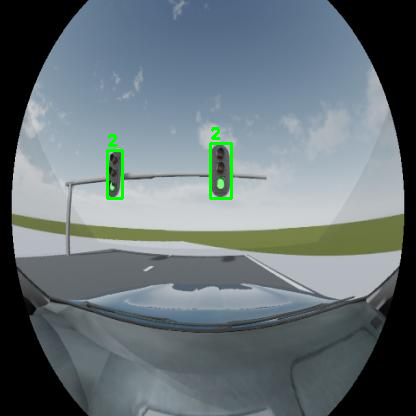

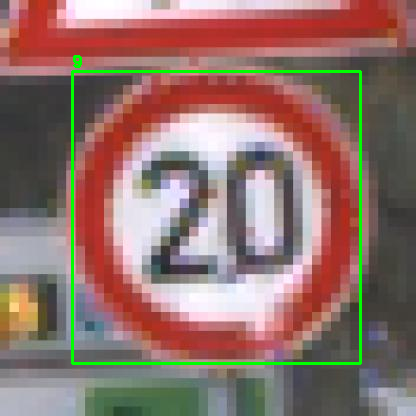

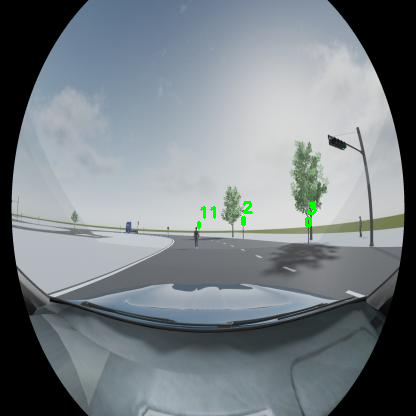

In [41]:
# Load the data, realized that not in order and missing some
train_labels = {}
train_images = []

# CONSTANTS
SAMPLE_SIZE = 5
CLASS_NAMES = [
    "Speed Limit 80",
    "Speed Limit 50",
    "Green Light",
    "Speed Limit 90",
    "Speed Limit 40",
    "Speed Limit 120",
    "Stop",
    "Speed Limit 60",
    "Speed Limit 70",
    "Speed Limit 20",
    "Speed Limit 110",
    "Red Light",
    "Speed Limit 30",
    "Speed Limit 100"
]

# May create a function for loading imgs
for id in os.listdir(os.path.join(base_path1, "train/labels/")):
    print(id)
    file_path = os.path.join(base_path1, "train/labels/", id)
    with open(file_path, 'r') as f:
        # Split each line into a list of values
        lines = f.readlines()
        id = id[:-4] # remove .txt
        train_labels[id] = [line.strip().split() for line in lines if line.strip()]

        if len(train_labels) == SAMPLE_SIZE:
            break

"""print(train_labels) # can have multiple labels in 1 image... rip
for (id, _) in train_labels.items():
    file_path = os.path.join(base_path1, f"train/images/{id}.jpg")
    img = cv2.imread(file_path)
    train_images[id] = img

cv2_imshow(img)"""

# draw the bouding boxes
def draw_box(img, labels, class_names=None, color_map=None):
    """
    Draw YOLO bounding boxes on a loaded image.

    Args:
        img (np.ndarray): The image already loaded via cv2.imread().
        labels (list[list[str]]): Each line = [class_id, x_center, y_center, width, height]
        class_names (list[str], optional): Optional human-readable class names.
        color_map (dict, optional): Optional map of class_id -> (B, G, R) color.
    """
    h, w, _ = img.shape
    annotated = img.copy()

    for line in labels:
        class_id = int(line[0])
        x_center, y_center, bw, bh = map(float, line[1:])

        # Convert YOLO normalized coords → pixel coords
        x_center *= w
        y_center *= h
        bw *= w
        bh *= h

        x1 = int(x_center - bw / 2)
        y1 = int(y_center - bh / 2)
        x2 = int(x_center + bw / 2)
        y2 = int(y_center + bh / 2)

        # Color (use provided map or default green)
        if color_map:
            color = color_map.get(class_id, (0, 255, 0))
        else:
            color = (0, 255, 0)

        # Draw box
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

        # Label text
        label_text = str(class_id)
        if class_names and class_id < len(class_names):
            label_text = class_names[class_id]

        cv2.putText(
            annotated,
            label_text,
            (x1, max(y1 - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    return annotated


for (id, _) in train_labels.items():
    file_path = os.path.join(base_path1, f"train/images/{id}.jpg")
    img = cv2.imread(file_path)
    boxed_img = draw_box(img, train_labels[id], class_names=None, color_map=None)
    cv2_imshow(boxed_img)
    train_images.append(boxed_img)



In [42]:

# Load all labels and count instance using a df is better
labels_path = os.path.join(base_path1, "train/labels")

all_labels = []

# Loop through all label files
for file_name in os.listdir(labels_path):
    if not file_name.endswith(".txt"):
        continue

    with open(os.path.join(labels_path, file_name), "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = int(parts[0])
                all_labels.append(class_id)

# Create a DataFrame and count class occurrences
df = pd.DataFrame(all_labels, columns=["class_id"])
class_counts = df["class_id"].value_counts().sort_index().reset_index()
class_counts.columns = ["class_id", "count"]

print(class_counts)

    class_id  count
0          0    308
1          1    281
2          2    532
3          3    168
4          4    244
5          5    252
6          6    290
7          7    297
8          8    319
9          9    264
10        10     99
11        11    553
12        12    326
13        13    258


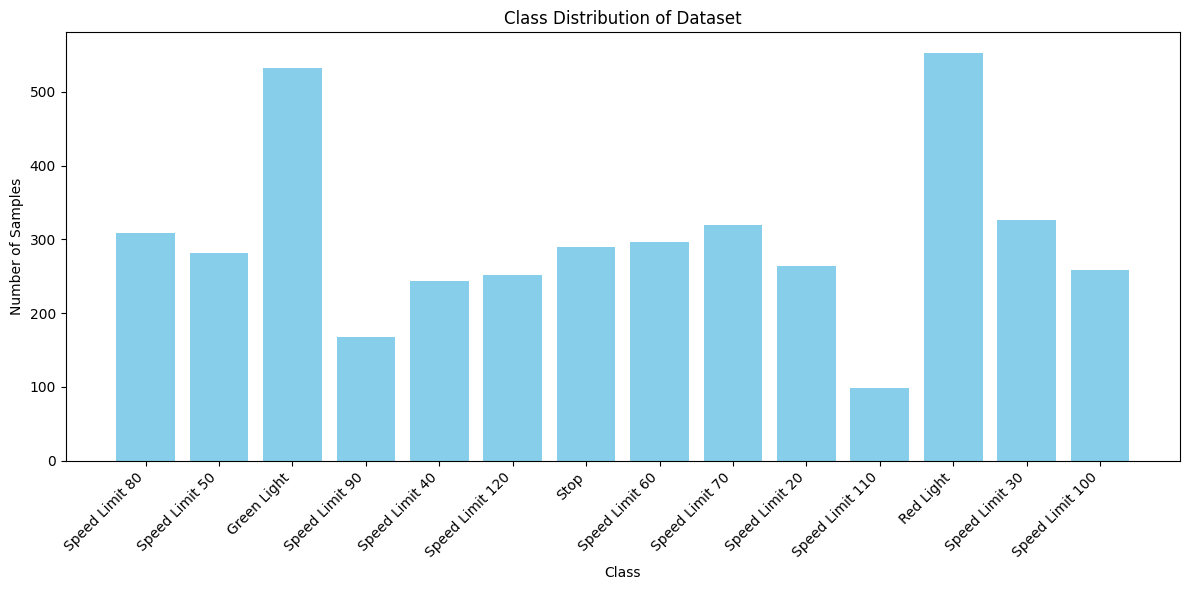

In [43]:
# Bar chart
class_counts["class_name"] = CLASS_NAMES

plt.figure(figsize=(12,6))
plt.bar(class_counts["class_name"], class_counts["count"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Dataset")
plt.tight_layout()
plt.show()

#### Discussion: Class Imbalance

The table below shows the number of occurrences for each class in the dataset:

| class_id | count |
|----------|-------|
| 0        | 308   |
| 1        | 281   |
| 2        | 532   |
| 3        | 168   |
| 4        | 244   |
| 5        | 252   |
| 6        | 290   |
| 7        | 297   |
| 8        | 319   |
| 9        | 264   |
| 10       | 99    |
| 11       | 553   |
| 12       | 326   |
| 13       | 258   |


The dataset exhibits noticeable class imbalance, which can significantly impact model training and evaluation:

Underrepresented classes: For example, class 10 (Speed Limit 110) has only 99 samples, while classes 2 (Green Light) and 11 (Red Light) have over 500 samples each. Models trained on this dataset may underperform on rare classes due to insufficient examples.

Overrepresented classes: Classes like 2 and 11 may dominate the training process, causing the model to bias predictions towards these frequent classes.

Impact on metrics: Accuracy alone may be misleading because predicting frequent classes correctly can inflate overall accuracy while rare classes are poorly predicted. Metrics like F1-score, balanced accuracy, or per-class precision/recall are recommended.

Potential mitigations:

Oversampling the minority classes or undersampling the majority classes.

Using class-weighted loss functions during training.

Data augmentation specifically for underrepresented classes.

Overall, careful handling of class imbalance is critical to ensure the model performs well across all classes, not just the most frequent ones.

### 1.2 Preprocess the Data

In [44]:
# Resize the input image -- should all be squared
def resize_image(img, target_size=(256, 256)):
    return cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

# but during comp, maybe do resize with aspect ratio
def resize_with_aspect_ratio(img, target_size=256):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(w*scale), int(h*scale)
    resized = cv2.resize(img, (new_w, new_h))
    # Pad to target_size
    top = (target_size - new_h) // 2
    bottom = target_size - new_h - top
    left = (target_size - new_w) // 2
    right = target_size - new_w - left
    return cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0,0,0])

# normalize values -- img is grayscaled
def norm_img(img):
    return img / 255.0

In [45]:
# Dataset Preparation
from sklearn.model_selection import train_test_split

# Suppose you have lists:
# images_list -> list of np.arrays
# labels_list -> list of class ids (integers)

# --- Dataset preparation ---
train_images = np.array(train_images)

# Stratification: take first object class for each image
strat_labels = [int(labels[0][0]) for labels in train_labels.values()]

# Split train/validation
X_train, X_val, y_train, y_val = train_test_split(
    train_images,
    strat_labels,
    test_size=0.3,
    random_state=42,
    stratify=None # do not care if set is balanced or not
)

print("Train images:", X_train.shape)
print("Validation images:", X_val.shape)

Train images: (3, 416, 416, 3)
Validation images: (2, 416, 416, 3)


## 2. Baseline Methods

### 2.1 Implementation of Baseline Object Recognition

In [46]:
!pip install ultralytics


In [ ]:
# New model

from ultralytics import YOLO
import yaml
import os
import torch
import random
import shutil # We no longer need this, but leaving it in case you revert
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# CUDA / GPU Info
# ------------------------------
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Device count:", torch.cuda.device_count())
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("⚠️ CUDA not available — training will run on CPU.")

# ------------------------------
# Define base paths and classes
# ------------------------------
# base_path1 = "Road_Signs_Detection_Dataset"
base_path1 = "/content/drive/MyDrive/ECSE415/a4/ecse-415-object-recognition/Road_Signs_Detection_Dataset"

train_img_dir = os.path.join(base_path1, "train/images")

# --- We no longer need these val paths ---
# val_img_dir = os.path.join(base_path1, "val/images")
# val_lbl_dir = os.path.join(base_path1, "val/labels")
# os.makedirs(val_img_dir, exist_ok=True)
# os.makedirs(val_lbl_dir, exist_ok=True)

CLASS_NAMES = [
    'stop', 'yield', 'speed_limit', 'no_entry', 'turn_left', 'turn_right',
    'pedestrian', 'school_zone', 'railroad_crossing', 'construction',
    'traffic_light', 'roundabout', 'parking', 'bicycle'
]

# ----------------------------------------------------
# Split train -> train.txt + val.txt (No File Copy)
# ----------------------------------------------------
val_ratio = 0.2  # 20% of training data for validation

# List all image files and get their absolute paths
images = [f for f in os.listdir(train_img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
image_paths = [os.path.join(os.path.abspath(train_img_dir), img) for img in images]
random.shuffle(image_paths)

num_val = int(len(image_paths) * val_ratio)
val_paths = image_paths[:num_val]
train_paths = image_paths[num_val:]

print(f"Total images: {len(image_paths)}")
print(f"Using {len(train_paths)} images for training.")
print(f"Using {len(val_paths)} images for validation (from the same directory).")

# --- Write the .txt files ---
# These files will be saved in the current working directory
train_txt_path = os.path.join(os.getcwd(), 'train.txt')
val_txt_path = os.path.join(os.getcwd(), 'val.txt')

with open(train_txt_path, 'w') as f:
    f.write('\n'.join(train_paths))

with open(val_txt_path, 'w') as f:
    f.write('\n'.join(val_paths))

print(f"\n✅ Created {train_txt_path}")
print(f"✅ Created {val_txt_path}")


# --- This file-copying section is no longer needed ---
# print(f"Total images: {len(images)}")
# print(f"Creating validation split: {len(val_images)} images (≈{val_ratio*100:.0f}% of training data)")
#
# for img in val_images:
#     img_src = os.path.join(train_img_dir, img)
#     lbl_src = os.path.join(train_lbl_dir, os.path.splitext(img)[0] + ".txt")
#
#     img_dst = os.path.join(val_img_dir, img)
#     lbl_dst = os.path.join(val_lbl_dir, os.path.splitext(img)[0] + ".txt")
#
#     shutil.copy(img_src, img_dst)
#     if os.path.exists(lbl_src):
#         shutil.copy(lbl_src, lbl_dst)
# ----------------------------------------------------


# ------------------------------
# Create dataset.yaml
# ------------------------------

# *** KEY CHANGE ***
# We now point 'train' and 'val' to the .txt files
# We also add 'path' as the root directory, which is good practice.
dataset_yaml = {
    'path': os.path.abspath(os.getcwd()), # Root directory
    'train': train_txt_path,  # Path to train.txt
    'val': val_txt_path,      # Path to val.txt
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES
}

yaml_path = os.path.join(os.getcwd(), 'dataset.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f)

print("\n✅ dataset.yaml created successfully (pointing to .txt files):")
with open(yaml_path, 'r') as f:
    print(f.read())

# ------------------------------
# Train YOLO model
# ------------------------------
print("\n🚀 Starting YOLO training...")
model = YOLO('yolov8n.pt')  # You can change to yolov8s.pt, yolov8m.pt, etc.

results = model.train(
    data=yaml_path,
    epochs=1,       # quick test
    imgsz=256,
    batch=8,
    lr0=1e-2,
    patience=3,
    device=0 if torch.cuda.is_available() else 'cpu',
    name='road_signs_fast_test'
)

# ------------------------------
# Validate model and print metrics
# ------------------------------
print("\n📊 Evaluating model on validation set...")
# Note: model.val() will automatically use the 'val' set from your .yaml
metrics = model.val()
print(metrics)

# ------------------------------
# Plotting and Results (Unchanged)
# ------------------------------
print("\n📊 Extracting results from training run...")

# Extract metrics from the 'results' object
map50 = results.box.map50      # mAP at IoU = 0.50
map5095 = results.box.map      # mAP averaged from 0.50–0.95

# Per-class precision, recall, and F1
prec = np.array(results.box.p)
rec = np.array(results.box.r)
f1_scores = np.array(results.box.f1)
avg_f1 = np.mean(f1_scores)

print("\n📊 Evaluation Results:")
for name, f1 in zip(results.names.values(), f1_scores):
    print(f"{name:20s} F1 = {f1:.3f}")

print(f"\nAverage F1-score: {avg_f1:.3f}")
print(f"mAP@50: {map50:.3f}")
print(f"mAP@50–95: {map5095:.3f}")

cm = results.confusion_matrix.matrix  # shape: [num_classes, num_classes]
labels = list(results.names.values())

# Add a check for an empty confusion matrix (can happen on very short runs)
if cm.size == 0:
    print("\n⚠️ Confusion matrix is empty. Skipping plot.")
else:
    # Normalize for readability (each row sums to 1)
    cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-6)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues",
        cbar=False
    )
    # %matplotlib inline # This line is only for Jupyter/IPython.
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("YOLOv8 Confusion Matrix (Normalized)")
    plt.tight_layout()
    plt.show()

print("\n✅ Training and evaluation complete.")

CUDA available: True
CUDA version: 12.6
Device count: 1
Device name: Tesla T4
Total images: 3464
Using 2772 images for training.
Using 692 images for validation (from the same directory).

✅ Created /content/train.txt
✅ Created /content/val.txt

✅ dataset.yaml created successfully (pointing to .txt files):
names:
- stop
- yield
- speed_limit
- no_entry
- turn_left
- turn_right
- pedestrian
- school_zone
- railroad_crossing
- construction
- traffic_light
- roundabout
- parking
- bicycle
nc: 14
path: /content
train: /content/train.txt
val: /content/val.txt


🚀 Starting YOLO training...
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True

In [ ]:
# !pip install ultralytics
# from ultralytics import YOLO

# import yaml

# dataset_yaml = {
#     'train': f'{base_path1}/train/images',
#     'val': f'{base_path1}/test/images',  # use test as validation, must split train for validation instead, 30%
#     'nc': 14,  # <-- change this to the number of classes in your dataset
#     'names': CLASS_NAMES  # change these names
# }

# with open('dataset.yaml', 'w') as f:
#     yaml.dump(dataset_yaml, f)

# !cat dataset.yaml

# model = YOLO('yolov8n.pt')  # small model (fast). Alternatives: yolov8s.pt, yolov8m.pt, yolov8l.pt

# """results = model.train(
#     data='dataset.yaml',
#     epochs=50,              # adjust as needed
#     imgsz=416,              # input image size
#     batch=8,                # batch size
#     lr0=1e-3,               # initial learning rate
#     patience=10,            # early stopping
#     name='road_signs_yolov8' # experiment name
# )"""

# results = model.train(
#     data='dataset.yaml',
#     epochs=5,        # only 5 for quick test
#     imgsz=256,       # lower resolution
#     batch=8,
#     lr0=1e-2,
#     patience=3,
#     device=0,
#     name='road_signs_fast_test'
# )

# metrics = model.val()
# print(metrics)

### 2.2 Analysis of Baseline Results

## 3. Model Implementation

### 3.1 Choose a Model

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

### 3.2 Optional Data Augmentation

### 3.3 Train the Model

In [ ]:
# Adjust these paths to your folder structure in Colab / Drive
DATA_ROOT = "/content/drive/MyDrive/ECSE415/a4/ecse-415-object-recognition/Road_Signs_Detection_Dataset"

TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train", "images")
TRAIN_LABEL_DIR = os.path.join(DATA_ROOT, "train", "labels")

TEST_IMG_DIR = os.path.join(DATA_ROOT, "test", "images")

class TrafficSignDataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
        self.transforms = transforms

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Load image
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        # Label file
        label_name = img_name.replace(".jpg", ".txt")
        label_path = os.path.join(self.label_dir, label_name)

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue

                    class_id, xc, yc, w, h = map(float, parts)

                    # YOLO normalized -> pixels
                    xc_abs = xc * W
                    yc_abs = yc * H
                    w_abs = w * W
                    h_abs = h * H

                    xmin = xc_abs - w_abs / 2
                    xmax = xc_abs + w_abs / 2
                    ymin = yc_abs - h_abs / 2
                    ymax = yc_abs + h_abs / 2

                    boxes.append([xmin, ymin, xmax, ymax])

                    # Classes 0–13 -> 1–14 (0 = background)
                    labels.append(int(class_id) + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

# Basic transform: just tensor
basic_transform = transforms.ToTensor()

full_dataset = TrafficSignDataset(
    img_dir=TRAIN_IMG_DIR,
    label_dir=TRAIN_LABEL_DIR,
    transforms=basic_transform
)

print("Total images in full dataset:", len(full_dataset))

# Split into train and val (we won't *use* val yet, but it's good to have)
total_size = len(full_dataset)
train_size = int(0.7* total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

# collate_fn so detection model gets lists of images/targets
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets

train_loader = DataLoader(
    train_dataset,
    batch_size=4,        # you can change batch size
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

# quick sanity check
images, targets = next(iter(train_loader))
print("One batch - num images:", len(images))
print("Image shape:", images[0].shape)
print("Boxes shape:", targets[0]["boxes"].shape)
print("Labels:", targets[0]["labels"])

In [ ]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

num_classes = 14 + 1  # 14 classes + background

# Load pretrained Faster R-CNN
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Replace classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)

# Set up optimizer + scheduler
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,        # you can tune this
    momentum=0.9,
    weight_decay=0.0005,
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

print("Model ready.")


In [ ]:
def train_one_epoch(model, optimizer, data_loader, device):
    model.train()
    total_loss = 0.0

    for images, targets in data_loader:
        # Move to device
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass returns a dict of losses
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    avg_loss = total_loss / len(data_loader)
    return avg_loss


In [ ]:
!nvidia-smi

In [ ]:
num_epochs = 5  # choose how many you want

train_losses = []

for epoch in range(num_epochs):
    avg_loss = train_one_epoch(model, optimizer, train_loader, device)
    train_losses.append(avg_loss)

    lr_scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Training loss: {avg_loss:.4f}")


## 4. Model Evaluation

### 4.1 Evaluate Performance

In [ ]:
# Recreate train/val split (IMPORTANT)
total_size = len(full_dataset)
train_size = int(0.8 * total_size)   # 80% train, 20% val
val_size = total_size - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))


In [ ]:
val_loader = DataLoader(
    val_dataset,
    batch_size=4,           # Same batch size as train
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("Validation loader ready.")



In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
from matplotlib import patches

# --------------------------
# IoU COMPUTATION
# --------------------------
def box_iou(box1, box2):
    """
    box1: (N, 4)
    box2: (M, 4)
    Both in xyxy format.
    """
    N = box1.shape[0]
    M = box2.shape[0]

    # Expand dims for broadcasting
    b1 = box1[:, None, :]  # (N,1,4)
    b2 = box2[None, :, :]  # (1,M,4)

    # Intersection
    xmin = torch.max(b1[..., 0], b2[..., 0])
    ymin = torch.max(b1[..., 1], b2[..., 1])
    xmax = torch.min(b1[..., 2], b2[..., 2])
    ymax = torch.min(b1[..., 3], b2[..., 3])

    inter = (xmax - xmin).clamp(min=0) * (ymax - ymin).clamp(min=0)

    # Union
    area1 = (b1[..., 2] - b1[..., 0]) * (b1[..., 3] - b1[..., 1])
    area2 = (b2[..., 2] - b2[..., 0]) * (b2[..., 3] - b2[..., 1])
    union = area1 + area2 - inter

    return inter / (union + 1e-6)


In [ ]:
model.eval()

all_true_labels = []
all_pred_labels = []
all_pred_scores = []

all_map_data = []   # For mAP calculation

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            gt_boxes = target["boxes"]
            gt_labels = target["labels"]

            pred_boxes = output["boxes"].cpu()
            pred_labels = output["labels"].cpu()
            pred_scores = output["scores"].cpu()

            # Store for mAP
            all_map_data.append({
                "gt_boxes": gt_boxes,
                "gt_labels": gt_labels,
                "pred_boxes": pred_boxes,
                "pred_labels": pred_labels,
                "pred_scores": pred_scores
            })

            # For confusion matrix & F1:
            # Match predictions with gt by IoU > 0.5
            iou_matrix = box_iou(pred_boxes, gt_boxes)

            used_gt = set()
            for i, pred_label in enumerate(pred_labels):
                # Best match
                max_iou, j = torch.max(iou_matrix[i], dim=0)
                if max_iou > 0.5 and j.item() not in used_gt:
                    all_pred_labels.append(pred_label.item())
                    all_true_labels.append(gt_labels[j].item())
                    used_gt.add(j.item())
                else:
                    # False positive
                    all_pred_labels.append(pred_label.item())
                    all_true_labels.append(0)  # 0 = background / no object


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

num_classes = 14  # only real classes (1–14)

# Remove class 0 (background)
filtered_true = [t for t in all_true_labels if t != 0]
filtered_pred = [p for t,p in zip(all_true_labels, all_pred_labels) if t != 0]

f1 = f1_score(filtered_true, filtered_pred, average='macro')
print("F1 Score (macro):", f1)

# Confusion matrix
cm = confusion_matrix(filtered_true, filtered_pred, labels=list(range(1, num_classes+1)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, num_classes+1)))

plt.figure(figsize=(10,10))
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
def compute_ap(rec, prec):
    """Compute AP from recall and precision."""
    rec = np.concatenate(([0.], rec, [1.]))
    prec = np.concatenate(([0.], prec, [0.]))

    for i in range(prec.size - 1, 0, -1):
        prec[i-1] = np.maximum(prec[i-1], prec[i])

    idx = np.where(rec[1:] != rec[:-1])[0]
    ap = np.sum((rec[idx + 1] - rec[idx]) * prec[idx + 1])
    return ap


def compute_map(all_data, iou_thresholds):
    aps = []

    for thr in iou_thresholds:
        tp = []
        fp = []
        scores = []
        n_positives = 0

        for d in all_data:
            gt_boxes = d["gt_boxes"]
            pred_boxes = d["pred_boxes"]
            pred_scores = d["pred_scores"]

            n_positives += len(gt_boxes)

            iou = box_iou(pred_boxes, gt_boxes)

            matched_gt = set()
            for i in range(len(pred_boxes)):
                scores.append(pred_scores[i].item())
                max_iou, j = torch.max(iou[i], dim=0)

                if max_iou > thr and j.item() not in matched_gt:
                    tp.append(1)
                    fp.append(0)
                    matched_gt.add(j.item())
                else:
                    tp.append(0)
                    fp.append(1)

        scores = np.array(scores)
        tp = np.array(tp)
        fp = np.array(fp)

        idx = np.argsort(-scores)
        tp = tp[idx]
        fp = fp[idx]

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)

        rec = tp_cum / (n_positives + 1e-6)
        prec = tp_cum / (tp_cum + fp_cum + 1e-6)

        aps.append(compute_ap(rec, prec))

    return np.mean(aps)

# mAP@50
map50 = compute_map(all_map_data, [0.5])
# mAP@50-95
map5095 = compute_map(all_map_data, np.arange(0.5, 1.0, 0.05))

print("mAP@50:     ", map50)
print("mAP@50–95:  ", map5095)


### 4.2 Visualize Results

In [ ]:
def visualize_prediction(image, boxes, labels, scores, score_thresh=0.5):
    image = image.permute(1,2,0).numpy()
    fig, ax = plt.subplots(1, figsize=(6,6))
    ax.imshow(image)

    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(xmin, ymin, f'{label} ({score:.2f})', color='yellow', fontsize=8)

    plt.axis('off')
    plt.show()


# Show 5 validation samples
model.eval()
count = 0

with torch.no_grad():
    for images, targets in val_loader:
        for img in images:
            if count >= 5:
                break

            output = model([img.to(device)])[0]

            visualize_prediction(
                img.cpu(),
                output["boxes"].cpu(),
                output["labels"].cpu(),
                output["scores"].cpu(),
                score_thresh=0.5
            )
            count += 1

    print("Displayed 5 validation predictions.")


### 4.3 Generalization Test

## 5. Prediction & Kaggle Competition

### 5.1 Generate Test Predictions and Prepare Submission File

### 5.2 Kaggle Submission

## 6. Report
See separate PDF